#LAB-2

#1 Repository selection
FastAPI


#C) Identification of Bug-Fixing Commits

Requirements: Pydriller and Pre trained LLM Model

In [ ]:
!pip install pydriller

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 5.3 MB/s eta 0:00:00


In [ ]:
from pydriller import Repository
import csv

#Keywords which are generally find in commits related to bug fixing
bug_keywords = ['fix', 'bug', 'error', 'issue',  'resolve', 'correction','fixed','fixed error','fix this','incorrect','to be resolved',
                'to be fixed','issue to be resolved','refactor']

# Path to FastAPI repo
REPO_PATH = 'https://github.com/fastapi/fastapi'

with open('bug_fixes.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)

    # As per the given question
    writer.writerow(['Hash', 'Message', 'Hashes of parents', 'Is a merge commit?', 'List of modified files'])

    for commit in Repository(REPO_PATH).traverse_commits():
        msg_lower = commit.msg.lower()

        if any(keyword in msg_lower for keyword in bug_keywords):
            commit_hash = commit.hash
            message = commit.msg
            parents = [p for p in commit.parents]
            is_merge = len(parents) > 1
            modified_files = [mod.filename for mod in commit.modified_files]

            writer.writerow([commit_hash, message, parents, is_merge, modified_files])

print("Bug-fixing commit CSV generated: bug_fixes.csv")


Bug-fixing commit CSV generated: bug_fixes.csv


#D) Diff Extraction
For each modified file (in the previous step),we have the diff csv files where the difference between these files is stored

In [ ]:
from pydriller import Repository
import csv


bug_keywords = ['fix', 'bug', 'error', 'issue',  'resolve', 'correction','fixed','fixed error','fix this','incorrect','to be resolved',
                'to be fixed','issue to be resolved','refactor']
# Path to clone FastAPI repo
REPO_PATH = 'https://github.com/fastapi/fastapi'

with open('bug_fixes_diffs.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow([
        'Hash', 'Message', 'Filename', 'Source Code (before)',
        'Source Code (current)', 'Diff', 'LLM Inference (fix type)', 'Rectified Message'
    ])

    for commit in Repository(REPO_PATH).traverse_commits():
        msg_lower = commit.msg.lower()

        if any(keyword in msg_lower for keyword in bug_keywords):
            for mod in commit.modified_files:
                writer.writerow([
                    commit.hash,
                    commit.msg,
                    mod.filename,
                    mod.source_code_before if mod.source_code_before else '',
                    mod.source_code if mod.source_code else '',
                    mod.diff if mod.diff else '',
                    '',  # Placeholder for LLM Inference (fix type)
                    ''   # Placeholder for Rectified Message
                ])

print("Detailed diff CSV generated: bug_fixes_diffs.csv")


Detailed diff CSV generated: bug_fixes_diffs.csv


Now using the given LLM model from the Hugging Face and feeding the Diff as the Input. For the given LLM Inference (fix type), we will get the rectified message. We will store this information in the previous csv file and also the rectified message.

Since my FastAPI Repository has 3000 Commits which were taking so much time to run, so I tried for 200 Commits from the csv file to feed into the model.


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Loading diff csv
df = pd.read_csv("bug_fixes_diffs.csv").head(200)

# 2. Loading the LLM model and tokenizer
model_name = "mamiksik/CommitPredictorT5"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def predict_commit_message(diff_text):
    """Generate commit message prediction from diff."""
    # Prepare model input (truncate if too long)
    inputs = tokenizer(diff_text, return_tensors="pt", truncation=True, max_length=512)

    # Generate prediction
    outputs = model.generate(**inputs, max_length=64, num_beams=4, early_stopping=True)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return prediction

# 3. Process each row in CSV
fix_types = []
rectified_msgs = []

for _, row in df.iterrows():
    # Ensure we always have a string
    diff_text = str(row["Diff"]) if pd.notna(row["Diff"]) else ""

    # Skip empty diffs
    if not diff_text.strip():
        fix_types.append("No Diff")
        rectified_msgs.append("")
        continue

    # Use model to predict a commit message
    rectified_msg = predict_commit_message(diff_text)

    # heuristic for fix type extraction
    msg_lower = rectified_msg.lower()
    if "fix" in msg_lower and not msg_lower.startswith("prefix"):
        fix_type = "Bug Fix"
    elif "refactor" in msg_lower:
        fix_type = "Refactor"
    elif any(word in msg_lower for word in ["add", "implement", "introduce"]):
        fix_type = "Feature Addition"
    else:
        fix_type = "Other"

    fix_types.append(fix_type)
    rectified_msgs.append(rectified_msg)


# 4. Add results to DataFrame
df["LLM Inference (fix type)"] = fix_types
df["Rectified Message"] = rectified_msgs

# 5. Save updated CSV
df.to_csv("bug-fixing-diff-llm.csv", index=False)

print("Updated CSV saved as bug-fixing-diff-llm.csv")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Updated CSV saved as bug-fixing-diff-llm.csv


#E) Rectifier Formulation:

In [ ]:
def rectifier(row):
    """
    Rectify commit messages at file-level using LLM + heuristics.
    Takes a DataFrame row (with Diff, Filename, Message, Rectified Message).
    Returns a refined commit message string.
    """
    diff_text = str(row["Diff"])
    orig_msg = str(row["Message"])
    llm_msg = str(row["Rectified Message"])
    filename = str(row["Filename"])

    # If docs or test file, assign special labels
    if "test" in filename.lower():
        return "Update test cases"
    elif "doc" in filename.lower() or filename.endswith(".md"):
        return "Update documentation"

    # If LLM prediction is empty, fallback to original message
    if not llm_msg.strip():
        return orig_msg

    # If LLM prediction is too generic, enrich with filename
    if "fix" in llm_msg.lower() and len(llm_msg.split()) < 4:
        return f"{llm_msg} in {filename}"

    return llm_msg


#F) Evaluation: Research Questions:



RQ1 Developer :

In [ ]:
def is_precise(msg):
    keywords = ['fix', 'bug', 'error', 'issue', 'refactor', 'add', 'update']
    return any(k in msg.lower() for k in keywords)

df["Developer Precise?"] = df["Message"].apply(is_precise)
rq1_hit_rate = df["Developer Precise?"].mean()
print("RQ1 Hit Rate:", rq1_hit_rate)


RQ1 Hit Rate: 1.0


RQ2:

In [ ]:
df["LLM Precise?"] = df["Rectified Message"].apply(is_precise)
rq2_hit_rate = df["LLM Precise?"].mean()
print("RQ2 Hit Rate:", rq2_hit_rate)


RQ2 Hit Rate: 0.92


RQ3

In [ ]:
df["Rectified Final"] = df.apply(rectifier, axis=1)
df["Rectifier Precise?"] = df["Rectified Final"].apply(is_precise)
rq3_hit_rate = df["Rectifier Precise?"].mean()
print("RQ3 Hit Rate:", rq3_hit_rate)


RQ3 Hit Rate: 0.985


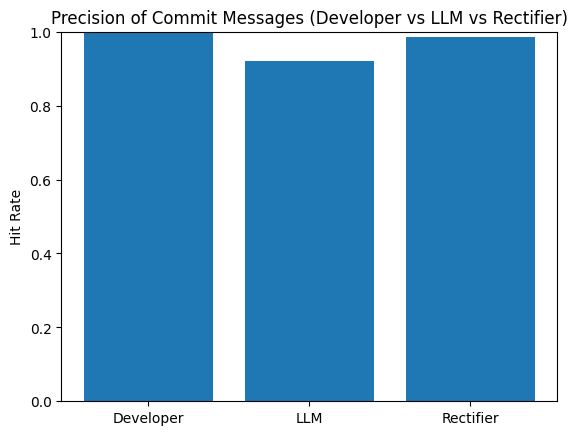

In [ ]:
import matplotlib.pyplot as plt

hit_rates = [rq1_hit_rate, rq2_hit_rate, rq3_hit_rate]
labels = ["Developer", "LLM", "Rectifier"]

plt.bar(labels, hit_rates)
plt.ylabel("Hit Rate")
plt.title("Precision of Commit Messages (Developer vs LLM vs Rectifier)")
plt.ylim(0, 1)
plt.show()


#LAB-3

Requirement: All the requirements that were used in the lab 2.
Radon
CodeBert
SacreBLEU

In [ ]:
!pip install radon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00


B) Compute and report baseline descriptive statistics:

In [ ]:
import pandas as pd

# Loading fixing-diff-llm file
df = pd.read_csv("bug-fixing-diff-llm.csv")

# Total number of commits and files
total_commits = df["Hash"].nunique()   # unique commits
total_files = df["Filename"].nunique() # unique files

# (2) Average number of modified files per commit
files_per_commit = df.groupby("Hash")["Filename"].nunique()
avg_files_per_commit = files_per_commit.mean()

# (3) Distribution of fix types (from LLM Inference column)
fix_type_distribution = df["LLM Inference (fix type)"].value_counts()

# (4) Most frequently modified filenames/extensions
# Extract file extensions
df["Extension"] = df["Filename"].apply(lambda x: x.split(".")[-1] if "." in str(x) else "no_ext")
extension_distribution = df["Extension"].value_counts()

# Print results
print("Baseline Descriptive Statistics")
print("Total number of commits:", total_commits)
print("Total number of files:", total_files)
print("Average modified files per commit:", avg_files_per_commit)
print("\nDistribution of fix types:\n", fix_type_distribution)
print("\nMost frequently modified file extensions:\n", extension_distribution)

# Optionally save summary to CSV
summary = {
    "Total Commits": [total_commits],
    "Total Files": [total_files],
    "Average Files per Commit": [avg_files_per_commit]
}
pd.DataFrame(summary).to_csv("baseline_statistics.csv", index=False)


Baseline Descriptive Statistics
Total number of commits: 57
Total number of files: 66
Average modified files per commit: 3.0350877192982457

Distribution of fix types:
 LLM Inference (fix type)
Feature Addition    149
Other                28
Bug Fix              14
No Diff               9
Name: count, dtype: int64

Most frequently modified file extensions:
 Extension
py      142
md       42
sh        6
yml       5
toml      4
png       1
Name: count, dtype: int64


C) Structural Metrics with radon:

In [ ]:
import pandas as pd
from radon.complexity import cc_visit
from radon.metrics import mi_visit, mi_parameters
from radon.raw import analyze

# Load dataset
df = pd.read_csv("bug-fixing-diff-llm.csv")

# Helper functions to extract metrics from source code
def get_metrics(source_code: str):
    if not isinstance(source_code, str) or source_code.strip() == "":
        return {"MI": 0, "CC": 0, "LOC": 0}

    try:
        # LOC metrics
        raw = analyze(source_code)
        loc = raw.loc

        # Cyclomatic Complexity (sum of CC for all blocks)
        cc_blocks = cc_visit(source_code)
        cc_total = sum(block.complexity for block in cc_blocks)

        # Maintainability Index
        mi_score = mi_visit(source_code, True)  # True → return float score
        return {"MI": mi_score, "CC": cc_total, "LOC": loc}

    except Exception:
        # If parsing fails (e.g., incomplete code snippet), return zeros
        return {"MI": 0, "CC": 0, "LOC": 0}

# New columns for metrics
MI_before, MI_after = [], []
CC_before, CC_after = [], []
LOC_before, LOC_after = [], []

# Iterate through dataset
for _, row in df.iterrows():
    before_code = row.get("Source Code (before)", "")
    after_code = row.get("Source Code (current)", "")

    metrics_before = get_metrics(before_code)
    metrics_after = get_metrics(after_code)

    MI_before.append(metrics_before["MI"])
    MI_after.append(metrics_after["MI"])

    CC_before.append(metrics_before["CC"])
    CC_after.append(metrics_after["CC"])

    LOC_before.append(metrics_before["LOC"])
    LOC_after.append(metrics_after["LOC"])

# Add columns to DataFrame
df["MI_Before"] = MI_before
df["MI_After"] = MI_after
df["CC_Before"] = CC_before
df["CC_After"] = CC_after
df["LOC_Before"] = LOC_before
df["LOC_After"] = LOC_after

# Compute changes
df["MI_Change"] = df["MI_After"] - df["MI_Before"]
df["CC_Change"] = df["CC_After"] - df["CC_Before"]
df["LOC_Change"] = df["LOC_After"] - df["LOC_Before"]

# Save updated CSV
df.to_csv("bug-fixing-diff-llm-with-metrics.csv", index=False)
print("Structural metrics computed and saved in bug-fixing-diff-llm-with-metrics.csv")


Structural metrics computed and saved in bug-fixing-diff-llm-with-metrics.csv


D)Change Magnitude Metrics:

In [ ]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
!pip install sacrebleu
import sacrebleu

# Loading the metrics csv
df = pd.read_csv("bug-fixing-diff-llm-with-metrics.csv")

# Load CodeBERT model for semantic similarity
model = SentenceTransformer("microsoft/codebert-base")

# Compute Semantic Similarity
def semantic_similarity(code_before, code_after):
    if not isinstance(code_before, str) or not isinstance(code_after, str):
        return 0.0
    emb1 = model.encode(code_before, convert_to_tensor=True)
    emb2 = model.encode(code_after, convert_to_tensor=True)
    return float(util.pytorch_cos_sim(emb1, emb2).item())

# Compute Token Similarity (BLEU score)
def token_similarity(code_before, code_after):
    if not isinstance(code_before, str) or not isinstance(code_after, str):
        return 0.0
    # sacrebleu expects list of references
    bleu = sacrebleu.corpus_bleu([code_after], [[code_before]])
    return bleu.score

# New columns
semantic_sims, token_sims = [], []

for _, row in df.iterrows():
    before_code = row.get("Source Code (before)", "")
    after_code = row.get("Source Code (current)", "")

    sem_sim = semantic_similarity(before_code, after_code)
    tok_sim = token_similarity(before_code, after_code)

    semantic_sims.append(sem_sim)
    token_sims.append(tok_sim)

df["Semantic_Similarity"] = semantic_sims
df["Token_Similarity"] = token_sims

# Save updated CSV
df.to_csv("bug-fixing-diff-llm-with-similarity.csv", index=False)
print("Added Semantic_Similarity and Token_Similarity columns")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.0 MB/s eta 0:00:00


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Added Semantic_Similarity and Token_Similarity columns


E)Classification & Agreement:

In [ ]:
import pandas as pd

# Load dataset with similarity scores
df = pd.read_csv("bug-fixing-diff-llm-with-similarity.csv")

# Thresholds (you can adjust later if TAs suggest)
SEMANTIC_THRESHOLD = 0.80
TOKEN_THRESHOLD = 0.75

# Classification functions
def classify_semantic(sim):
    if sim >= SEMANTIC_THRESHOLD:
        return "Minor"
    else:
        return "Major"

def classify_token(sim):
    if sim >= TOKEN_THRESHOLD:
        return "Minor"
    else:
        return "Major"

# Apply classifications
df["Semantic_class"] = df["Semantic_Similarity"].apply(classify_semantic)
df["Token_class"] = df["Token_Similarity"].apply(classify_token)

# Agreement check
df["Classes_Agree"] = df.apply(
    lambda row: "YES" if row["Semantic_class"] == row["Token_class"] else "NO",
    axis=1
)

# Save updated CSV
df.to_csv("bug-fixing-diff-llm-with-classes.csv", index=False)

print("Added Semantic_class, Token_class, and Classes_Agree columns")


Added Semantic_class, Token_class, and Classes_Agree columns


#LAB - 4

Requirement: Pydriller
SEART tool

In [ ]:
#git 1 link: https://github.com/aws/aws-sdk-pandas
#git 1 link: https://github.com/rpearce/react-medium-image-zoom
#git 1 link: https://github.com/dpgaspar/flask-appbuilder

'''
repos = [
    "https://github.com/aws/aws-sdk-pandas",
    "https://github.com/rpearce/react-medium-image-zoom",
    "https://github.com/dpgaspar/flask-appbuilder"
]
"""


Task C

In [1]:
# Clone the repos inside Colab
!git clone https://github.com/aws/aws-sdk-pandas.git
!git clone https://github.com/rpearce/react-medium-image-zoom.git
!git clone https://github.com/dpgaspar/flask-appbuilder.git


Cloning into 'aws-sdk-pandas'...
remote: Enumerating objects: 21992, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 21992 (delta 131), reused 94 (delta 94), pack-reused 21830 (from 3)
Receiving objects: 100% (21992/21992), 16.63 MiB | 13.04 MiB/s, done.
Resolving deltas: 100% (17076/17076), done.
Cloning into 'react-medium-image-zoom'...
remote: Enumerating objects: 11048, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 11048 (delta 218), reused 168 (delta 150), pack-reused 10783 (from 2)
Receiving objects: 100% (11048/11048), 105.12 MiB | 14.07 MiB/s, done.
Resolving deltas: 100% (7281/7281), done.
Cloning into 'flask-appbuilder'...
remote: Enumerating objects: 36047, done.
remote: Counting objects: 100% (530/530), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 36047 (delta 439), reused 378 (delta 360), pack-reused 35517 (

✅ CSV saved to consolidated_dataset.csv

📊 Mismatch Statistics:
  file_category  mismatch
0       LICENSE         0
1         Other       385
2        README        12
3   Source Code       351
4     Test Code        79


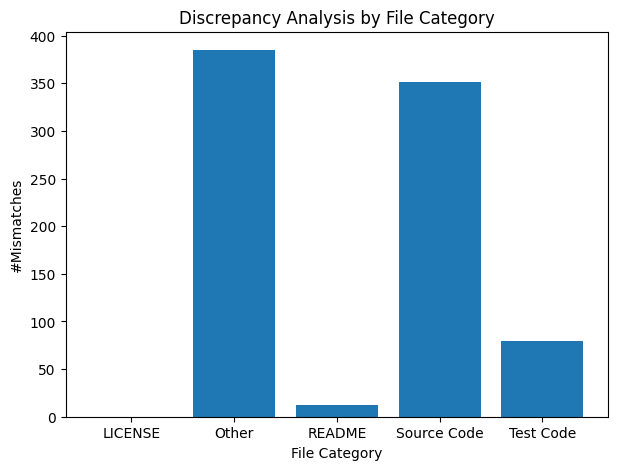

In [3]:
!pip install pydriller matplotlib

import csv
import subprocess
from pydriller import Repository
import pandas as pd
import matplotlib.pyplot as plt


# Repository Selection

repos = [
    "/content/aws-sdk-pandas",
    "/content/flask-appbuilder",
    "/content/react-medium-image-zoom"
]

output_file = "consolidated_dataset.csv"


# (c) Run PyDriller + Extract Data

with open(output_file, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "old_file_path",
        "new_file_path",
        "commit_sha",
        "parent_commit_sha",
        "commit_message",
        "diff_myers",
        "diff_hist",
        "discrepancy"
    ])

    for repo in repos:
        for commit in Repository(repo).traverse_commits():
            for mod in commit.modified_files:
                if mod.change_type.name == "MODIFY":
                    old_path = mod.old_path
                    new_path = mod.new_path
                    commit_sha = commit.hash
                    parent_sha = commit.parents[0] if commit.parents else None
                    message = commit.msg

                    diff_myers, diff_hist = "", ""

                    if parent_sha:
                        # Run git diff (Myers)
                        try:
                            diff_myers = subprocess.check_output(
                                ["git", "-C", repo, "diff", f"{parent_sha}", f"{commit_sha}",
                                 "-w", "--ignore-blank-lines", "--diff-algorithm=myers",
                                 "--", new_path or old_path],
                                stderr=subprocess.DEVNULL
                            ).decode("utf-8", errors="ignore")
                        except subprocess.CalledProcessError:
                            diff_myers = ""

                        # Run git diff (Histogram)
                        try:
                            diff_hist = subprocess.check_output(
                                ["git", "-C", repo, "diff", f"{parent_sha}", f"{commit_sha}",
                                 "-w", "--ignore-blank-lines", "--diff-algorithm=histogram",
                                 "--", new_path or old_path],
                                stderr=subprocess.DEVNULL
                            ).decode("utf-8", errors="ignore")
                        except subprocess.CalledProcessError:
                            diff_hist = ""

                    # (d) Discrepancy Analysis
                    discrepancy = "No" if diff_myers.strip() == diff_hist.strip() else "Yes"

                    writer.writerow([
                        old_path, new_path, commit_sha, parent_sha, message.strip(),
                        diff_myers.strip(), diff_hist.strip(), discrepancy
                    ])

print(f"✅ CSV saved to {output_file}")



# (e) Final Dataset Statistics

df = pd.read_csv(output_file)

# Identify file categories
def classify_file(path):
    if path is None:
        return "Other"
    path = path.lower()
    if "test" in path:
        return "Test Code"
    elif "readme" in path:
        return "README"
    elif "license" in path:
        return "LICENSE"
    elif path.endswith(".py") or path.endswith(".java") or path.endswith(".js"):
        return "Source Code"
    else:
        return "Other"

df["file_category"] = df["new_file_path"].apply(classify_file)
df["mismatch"] = df["discrepancy"] == "Yes"

# Count mismatches per category
mismatch_stats = df.groupby("file_category")["mismatch"].sum().reset_index()

print("\n📊 Mismatch Statistics:")
print(mismatch_stats)

# Plot mismatches
plt.figure(figsize=(7,5))
plt.bar(mismatch_stats["file_category"], mismatch_stats["mismatch"])
plt.xlabel("File Category")
plt.ylabel("#Mismatches")
plt.title("Discrepancy Analysis by File Category")
plt.show()


In [4]:
df.head(5)

,old_file_path,new_file_path,commit_sha,parent_commit_sha,commit_message,diff_myers,diff_hist,discrepancy,file_category,mismatch
0,README.md,README.md,50c27a85489de71210caf54f728c8ec88efb77e3,1b33e7b13c3be30fe29b7ad1f631fd8d2fd6c33a,Updating initial README.md from template,diff --git a/README.md b/README.md\nindex b1fc...,diff --git a/README.md b/README.md\nindex b1fc...,No,README,False
1,README.md,README.md,7aef14678a73e7e29ac65e702db8d3ad84b60d62,ad7135ca4d198ad365ead2b52a0207cb6429d34d,add source code,diff --git a/README.md b/README.md\nindex aaa1...,diff --git a/README.md b/README.md\nindex aaa1...,No,README,False
2,README.md,README.md,73f5745d0e2ef4303bbef98c1cd0ed42fc479b2c,7aef14678a73e7e29ac65e702db8d3ad84b60d62,Fix links in the README.md,diff --git a/README.md b/README.md\nindex f0a2...,diff --git a/README.md b/README.md\nindex f0a2...,No,README,False
3,README.md,README.md,625c7bd9d4fd586e914397cfcc1d2e32f0dec960,73f5745d0e2ef4303bbef98c1cd0ed42fc479b2c,Add BETA warning in README,diff --git a/README.md b/README.md\nindex 3f45...,diff --git a/README.md b/README.md\nindex 3f45...,No,README,False
4,README.md,README.md,44944e631f76244cdaf168230a07decf57ff95a0,625c7bd9d4fd586e914397cfcc1d2e32f0dec960,Update README.md,diff --git a/README.md b/README.md\nindex 6706...,diff --git a/README.md b/README.md\nindex 6706...,No,README,False
